
# Semantic Segmantation**

## Learning Objectives
* Understand semantic segmentation
* Recognise different models and approaches to segmentation
* Identify use cases for segmantic segmentation

Semantic Segmentation is best described as pixel-level classification.In traditional classification, you assign a label to an entire image (e.g., "This is a cell"). In object detection, you draw a bounding box around the cell. In semantic segmentation, you force the model to make a prediction for every single pixel in the high-dimensional input grid, outputting a label map of resolution. Semantic segmentation treats all objects of the same class as a single entity. e.g. If there are five distinct mitochondria in a microscopy slide, semantic segmentation labels all their pixels as "mitochondria" (class 1) without distinguishing instance #1 from instance #2.



In [1]:
# ----------------------------------------------------------------------
# Computer Vision Demo: Detection & Segmentation Workflow
# GDG AI for Science Workshop
# ----------------------------------------------------------------------
import os
import urllib.request
import numpy as np

# For plotting
import matplotlib.pyplot as plt

# For image manipulation
import cv2

# CV framework
import keras_hub
import keras

2026-07-23 03:45:37.919575: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-23 03:45:38.001275: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:

import kagglehub
kagglehub.login()

In [8]:
!wget -O segdemo.jpg https://upload.wikimedia.org/wikipedia/commons/thumb/9/9f/Photomicrograph_of_rock_thin_section_Gabbroic_inclusion.jpg/960px-Photomicrograph_of_rock_thin_section_Gabbroic_inclusion.jpg
!wget -O deeplab_v3.tflite https://storage.googleapis.com/mediapipe-models/image_segmenter/deeplab_v3/float32/1/deeplab_v3.tflite

--2026-07-23 02:27:29--  https://upload.wikimedia.org/wikipedia/commons/thumb/9/9f/Photomicrograph_of_rock_thin_section_Gabbroic_inclusion.jpg/960px-Photomicrograph_of_rock_thin_section_Gabbroic_inclusion.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 103.102.166.240, 2001:df2:e500:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|103.102.166.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 346782 (339K) [image/jpeg]
Saving to: ‘segdemo.jpg’

segdemo.jpg         100%[===================>] 338.65K  --.-KB/s    in 0.01s   

2026-07-23 02:27:29 (32.6 MB/s) - ‘segdemo.jpg’ saved [346782/346782]

--2026-07-23 02:27:29--  https://storage.googleapis.com/mediapipe-models/image_segmenter/deeplab_v3/float32/1/deeplab_v3.tflite
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.200.207, 74.125.68.207, 74.125.24.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.200.207|:443... connected.
HTTP 

Loading Keras Segment Anything Model (may take time on first run)...


2026-07-23 03:45:45.217486: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/google/home/butterworthnat/miniforge3/envs/caigt/lib/python3.12/site-packages/keras/src/layers/layer.py:431: UserWarning: `build()` was called on layer 'sam_image_segmenter', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(



--- Running Segmentation ---
Prompting model at coordinates: [512 512]


2026-07-23 03:45:56.677276: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 805306368 exceeds 10% of free system memory.
2026-07-23 03:45:56.772035: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 805306368 exceeds 10% of free system memory.
2026-07-23 03:45:58.285251: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 805306368 exceeds 10% of free system memory.
2026-07-23 03:45:58.432789: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 805306368 exceeds 10% of free system memory.
2026-07-23 03:45:59.779402: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 805306368 exceeds 10% of free system memory.


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step

--- Quantitative Analysis ---
Total Pixels: 65536
Object Pixels: 6939
Specimen Coverage: 10.59%
Displaying results plot...


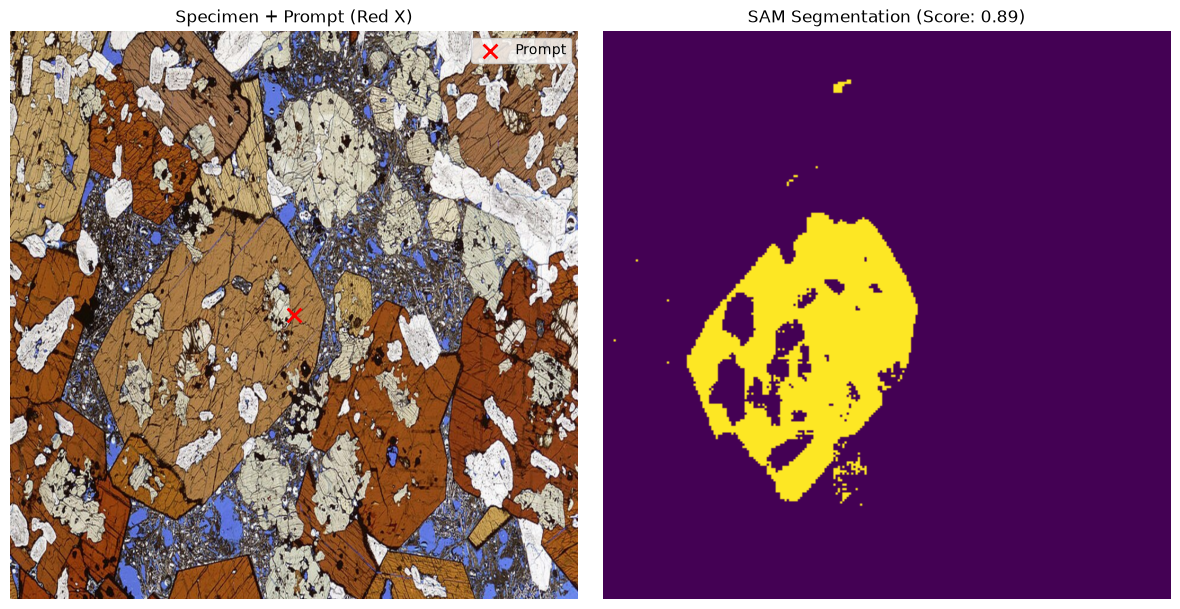

In [2]:
# Using a standard sample image
IMAGE_FILE = "segdemo.jpg"

print("Loading Keras Segment Anything Model (may take time on first run)...")

# We use the 'huge' (sam_h), 'large' (sam_l), or 'base' (sam_b) model.
# 'sam_b' is efficient enough for a laptop demo.
# This pulls the weights directly from Kaggle/KerasHub.
# model = keras_hub.models.SegmentAnythingModel.from_preset("sam_b")
model = keras_hub.models.SAMImageSegmenter.from_preset('sam_base_sa1b')

print("\n--- Running Segmentation ---")
# A. Load and Preprocess Image
# SAM expects specific dimensions (usually 1024x1024) for best performance
raw_img = cv2.imread(IMAGE_FILE)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
raw_img = cv2.resize(raw_img, (1024, 1024))
input_image = np.expand_dims(raw_img, axis=0)  # Add batch dimension

# B. Define the Prompt
# SAM works by "clicking" on the feature you want to detect - simulate that
# Coordinate format: [x, y]
center_x, center_y = 512, 512
input_points = np.array([[[center_x, center_y]]])
input_labels = np.array([[1]]) # 1 = Foreground point, 0 = Background point

print(f"Prompting model at coordinates: {input_points[0][0]}")

# C. Run Inference
# We pass the image and the prompt to the model
outputs = model.predict({
    "images": input_image,
    "points": input_points,
    "labels": input_labels
})

# D. Extract the best mask
# SAM returns multiple potential masks (masks) and quality scores (iou_pred).
# We take the one with the highest confidence score.
masks = outputs["masks"][0]
scores = outputs["iou_pred"][0]
best_mask_index = np.argmax(scores)
best_mask = masks[best_mask_index][:, :] # Extract the 2D mask


print("\n--- Quantitative Analysis ---")

# Threshold the mask (it outputs logits/probabilities) to get binary 0 or 1
binary_mask = (best_mask > 0.5).astype(int)

foreground_pixels = np.sum(binary_mask)
total_pixels = binary_mask.size
coverage_ratio = (foreground_pixels / total_pixels) * 100

print(f"Total Pixels: {total_pixels}")
print(f"Object Pixels: {foreground_pixels}")
print(f"Specimen Coverage: {coverage_ratio:.2f}%")

# VISUALISATION
print("Displaying results plot...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot Original with the "Click" point
ax1.imshow(raw_img)
ax1.scatter([center_x], [center_y], c='red', marker='x', s=100, linewidth=2, label='Prompt')
ax1.set_title("Specimen + Prompt (Red X)")
ax1.legend()
ax1.axis('off')

# Plot The Resulting Mask
ax2.imshow(binary_mask, cmap='viridis')
ax2.set_title(f"SAM Segmentation (Score: {scores[best_mask_index]:.2f})")
ax2.axis('off')

plt.tight_layout()

plt.show()

In [3]:
# !pip install ipympl

Loading Segment Anything Model...


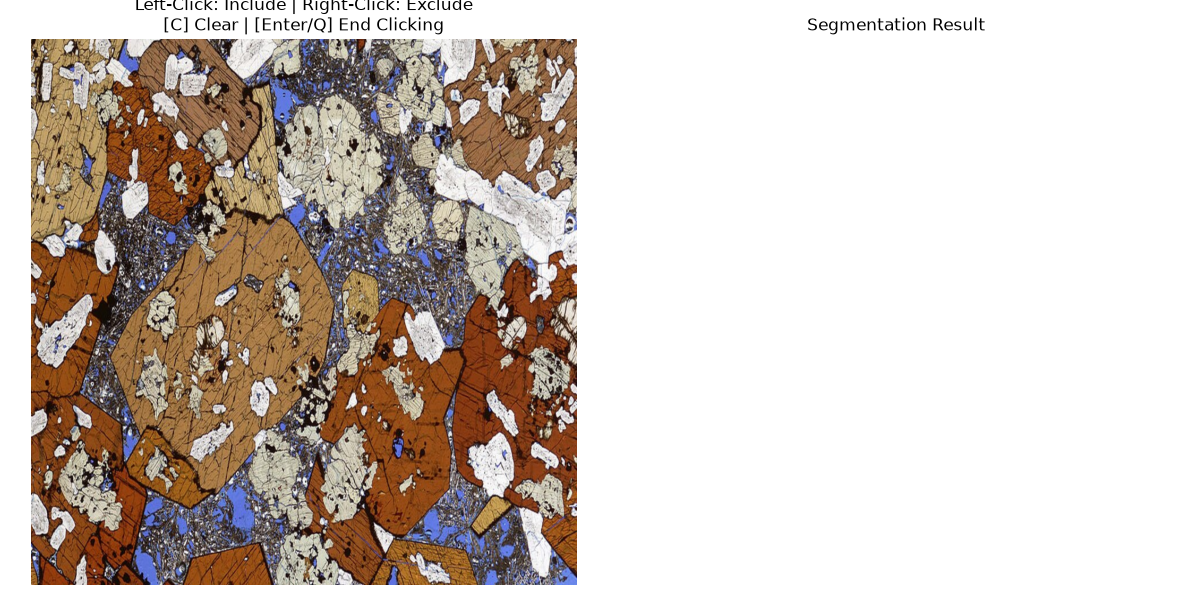

In [3]:
%matplotlib widget
import cv2
import numpy as np
import matplotlib.pyplot as plt
import keras_hub

# ---------------------------------------------------------
# 1. Load Model & Image
# ---------------------------------------------------------
IMAGE_FILE = "segdemo.jpg"

print("Loading Segment Anything Model...")
model = keras_hub.models.SAMImageSegmenter.from_preset('sam_base_sa1b')

raw_img = cv2.imread(IMAGE_FILE)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
raw_img = cv2.resize(raw_img, (1024, 1024))
input_image = np.expand_dims(raw_img, axis=0)

# Store lists of accumulated points and labels
clicked_points = []
clicked_labels = []

# ---------------------------------------------------------
# 2. Interactive Setup
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

def render_points():
    """Redraws points on the original image."""
    ax1.clear()
    ax1.imshow(raw_img)
    
    pts = np.array(clicked_points)
    lbls = np.array(clicked_labels)
    
    if len(pts) > 0:
        fg_pts = pts[lbls == 1]
        bg_pts = pts[lbls == 0]
        
        if len(fg_pts) > 0:
            ax1.scatter(fg_pts[:, 0], fg_pts[:, 1], c='lime', marker='o', s=90, edgecolors='black', label='Foreground (Left-Click)')
        if len(bg_pts) > 0:
            ax1.scatter(bg_pts[:, 0], bg_pts[:, 1], c='red', marker='x', s=90, linewidth=2, label='Background (Right-Click)')
            
        ax1.legend(loc='upper right', fontsize=8)
        
    ax1.set_title("Left-Click: Include | Right-Click: Exclude\n[C] Clear | [Enter/Q] End Clicking")
    ax1.axis('off')

render_points()
ax2.set_title("Segmentation Result")
ax2.axis('off')
plt.tight_layout()

# ---------------------------------------------------------
# 3. Mouse Click Handler
# ---------------------------------------------------------
def onclick(event):
    if event.inaxes != ax1 or event.xdata is None or event.ydata is None:
        return
    
    x, y = int(event.xdata), int(event.ydata)
    
    # Left click (button 1) = Foreground (1), Right click (button 3) = Background (0)
    label = 1 if event.button == 1 else 0
    
    clicked_points.append([x, y])
    clicked_labels.append(label)
    
    # Shape SAM expects: [batch_size, num_points, 2]
    input_points = np.array([clicked_points])
    input_labels = np.array([clicked_labels])
    
    # Run prediction
    outputs = model.predict({
        "images": input_image,
        "points": input_points,
        "labels": input_labels
    }, verbose=0)
    
    # Extract best mask
    masks = outputs["masks"][0]
    scores = outputs["iou_pred"][0]
    best_idx = np.argmax(scores)
    binary_mask = (masks[best_idx] > 0.5).astype(int)
    
    # Render updated UI
    render_points()
    ax2.clear()
    ax2.imshow(binary_mask, cmap='viridis')
    ax2.set_title(f"SAM Mask (Score: {scores[best_idx]:.2f})")
    ax2.axis('off')
    
    fig.canvas.draw_idle()

# ---------------------------------------------------------
# 4. Keyboard Listener to Reset ('c') or End ('q' / 'Enter')
# ---------------------------------------------------------
def onkey(event):
    global click_cid, key_cid
    key = event.key.lower() if event.key else ''
    
    if key == 'c':
        # Reset points
        clicked_points.clear()
        clicked_labels.clear()
        render_points()
        ax2.clear()
        ax2.set_title("Cleared - Click to start again")
        ax2.axis('off')
        fig.canvas.draw_idle()
        print("Points reset.")
        
    elif key in ['q', 'enter', 'escape']:
        # Disconnect click and key handlers
        fig.canvas.mpl_disconnect(click_cid)
        fig.canvas.mpl_disconnect(key_cid)
        
        ax1.set_title("Clicking Locked (Final Result)")
        fig.canvas.draw_idle()
        print(f"\n--- Clicking Session Ended ---")
        print(f"Final Prompt Count: {len(clicked_points)} points")

# Attach listeners
click_cid = fig.canvas.mpl_connect('button_press_event', onclick)
key_cid = fig.canvas.mpl_connect('key_press_event', onkey)

plt.show()

## MediaPipe
https://ai.google.dev/edge/mediapipe/solutions/vision/image_segmenter

In [ ]:
!pip install -U mediapipe

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 10.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled pr

In [5]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

ModuleNotFoundError: No module named 'mediapipe'


--- Initializing Model ---
--- Running Segmentation ---

 --- Quantitative Analysis ---
Total Pixels: 599040
Object Pixels: 75391
Specimen Coverage: 12.59%

--- Visualization ---


/usr/local/lib/python3.12/dist-packages/mediapipe/tasks/python/vision/image_segmenter.py:158: UserWarning: MessageFactory class is deprecated. Please use GetMessageClass() instead of MessageFactory.GetPrototype. MessageFactory class will be removed after 2024.
  graph_config = self._runner.get_graph_config()


Displaying results plot...


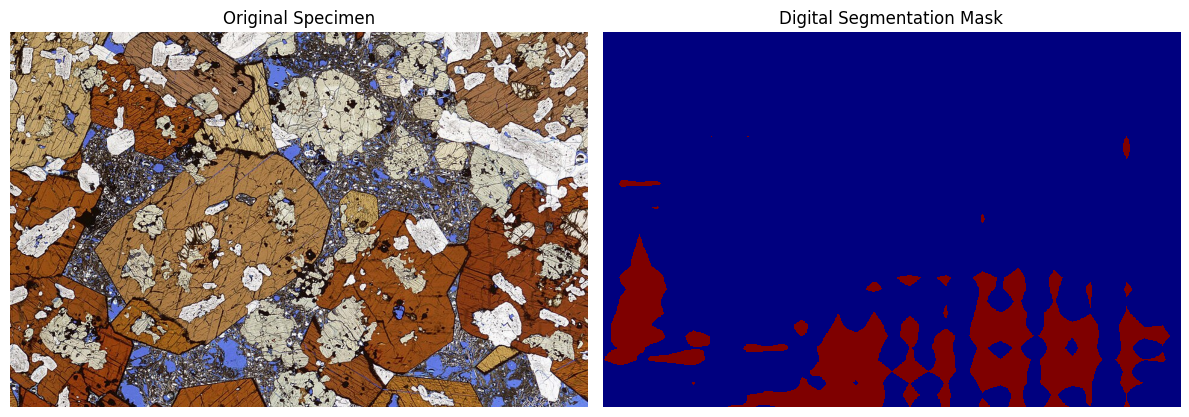

In [ ]:
# 1. SETUP & DATA ACQUISITION
MODEL_FILE = "deeplab_v3.tflite"
IMAGE_FILE = "segdemo.jpg"

print("\n--- Initialising Model ---")

base_options = python.BaseOptions(model_asset_path=MODEL_FILE)

# We want 'category_mask' output: each pixel gets an integer ID (0=background, 1=object, etc.)
options = vision.ImageSegmenterOptions(
    base_options=base_options,
    output_category_mask=True
)

# Create the segmenter
segmenter = vision.ImageSegmenter.create_from_options(options)

print("--- Running Segmentation ---")
# Load image using MediaPipe's format
image = mp.Image.create_from_file(IMAGE_FILE)

# Perform the segmentation
# This runs the neural network on the pixel data
segmentation_result = segmenter.segment(image)

# Extract the raw data (the mask)
# This is a 2D array where every number represents a category (class ID)
category_mask = segmentation_result.category_mask

print("\n --- Quantitative Analysis ---")

# Convert the MediaPipe mask to a standard NumPy array for math
mask_array = category_mask.numpy_view()

# In some segmentation workflows, specific indices correspond to classes.
# We will look for ANY object (index 1) that isn't background (index 0).
foreground_pixels = np.sum(mask_array > 0)
total_pixels = mask_array.size
coverage_ratio = (foreground_pixels / total_pixels) * 100

print(f"Total Pixels: {total_pixels}")
print(f"Object Pixels: {foreground_pixels}")
print(f"Specimen Coverage: {coverage_ratio:.2f}%")

# VISUALISATION
print("\n--- Visualisation ---")

# Create a figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot Original
ax1.imshow(image.numpy_view())
ax1.set_title("Original Specimen")
ax1.axis('off')

# Plot the mask,  map the classes to colors for visibility
ax2.imshow(mask_array, cmap='jet', interpolation='nearest')
ax2.set_title("Digital Segmentation Mask")
ax2.axis('off')

plt.tight_layout()
print("Displaying results plot...")
plt.show()
